In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    classification_report,

    roc_curve,

    roc_auc_score

)

import joblib

In [2]:
train_df = pd.read_csv("../data/train_clustered.csv")

train_df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Arrival Delay in Minutes,satisfaction,Overall_Service_Score,Comfort_Score,Digital_Experience,Total_Delay,Customer_Value,Travel_Experience,Cluster,Passenger_Segment
0,1,0,13.0,1,2,460.0,3.0,4.0,3.0,1.0,...,18.0,0,4.181818,4.333333,3.000000,43.0,1923.636364,3.838384,3,At-Risk Passengers
1,1,1,25.0,0,0,235.0,3.0,2.0,3.0,3.0,...,6.0,0,2.227273,2.333333,3.000000,7.0,523.409091,2.520202,2,Budget Frequent Travelers
2,0,0,26.0,0,0,1142.0,2.0,2.0,2.0,2.0,...,0.0,1,4.181818,4.333333,3.000000,0.0,4775.636364,3.838384,3,At-Risk Passengers
3,0,0,25.0,0,0,562.0,2.0,5.0,5.0,5.0,...,9.0,0,2.500000,3.000000,3.000000,20.0,1405.000000,2.833333,2,Budget Frequent Travelers
4,1,0,61.0,0,0,214.0,3.0,3.0,3.0,3.0,...,0.0,1,3.636364,4.000000,3.666667,0.0,778.181818,3.767677,3,At-Risk Passengers


In [3]:
drop_columns = [

    "satisfaction",

    "Passenger_Segment"

]

X = train_df.drop(columns=drop_columns)

y = train_df["satisfaction"]

In [4]:
print(y.value_counts())

print()

print(y.value_counts(normalize=True))

satisfaction
0    58879
1    45025
Name: count, dtype: int64

satisfaction
0    0.566667
1    0.433333
Name: proportion, dtype: float64


In [5]:
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [6]:
log_model = LogisticRegression(

    max_iter=1000,

    random_state=42

)

log_model.fit(

    X_train,

    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [7]:
prediction = log_model.predict(X_test)

probability = log_model.predict_proba(X_test)[:,1]

In [8]:
accuracy = accuracy_score(

    y_test,

    prediction
)

print("Accuracy :",accuracy)

Accuracy : 0.8650209325826476


In [9]:
precision = precision_score(

    y_test,

    prediction
)

print("Precision :",precision)

Precision : 0.8645343367826905


In [10]:
recall = recall_score(

    y_test,

    prediction
)

print("Recall :",recall)

Recall : 0.816435313714603


In [11]:
f1 = f1_score(

    y_test,

    prediction
)

print("F1 Score :",f1)

F1 Score : 0.8397966759952025


In [12]:
auc = roc_auc_score(

    y_test,

    probability
)

print("ROC AUC :",auc)

ROC AUC : 0.9204507648226831


In [13]:
print(

    classification_report(

        y_test,

        prediction

    )

)

              precision    recall  f1-score   support

           0       0.87      0.90      0.88     11776
           1       0.86      0.82      0.84      9005

    accuracy                           0.87     20781
   macro avg       0.86      0.86      0.86     20781
weighted avg       0.87      0.87      0.86     20781



In [14]:
cm = confusion_matrix(

    y_test,

    prediction

)

cm

array([[10624,  1152],
       [ 1653,  7352]])

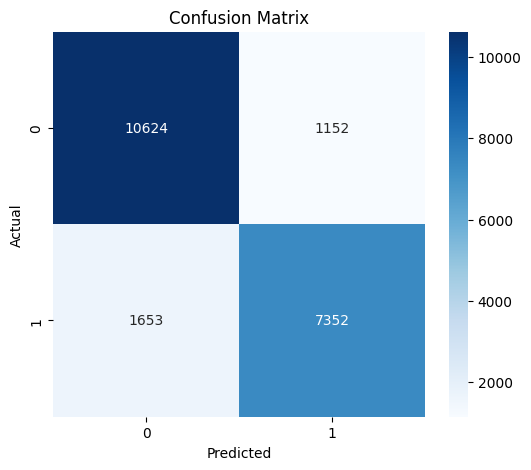

In [15]:
plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

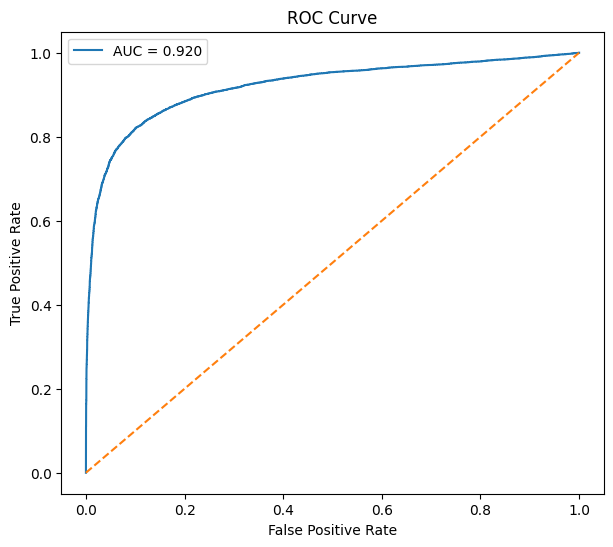

In [16]:
fpr,tpr,threshold = roc_curve(

    y_test,

    probability

)

plt.figure(figsize=(7,6))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    linestyle="--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [17]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":log_model.coef_[0]

})

importance = importance.sort_values(

    by="Coefficient",

    key=abs,

    ascending=False

)

importance.head(15)

,Feature,Coefficient
3,Type of Travel,-1.490292
4,Class,-1.145260
1,Customer Type,-0.892909
11,Online boarding,0.374779
6,Inflight wifi service,0.289001
13,Inflight entertainment,0.282630
8,Ease of Online booking,-0.259118
10,Food and drink,-0.171218
18,Inflight service,-0.153035
24,Digital_Experience,0.134887


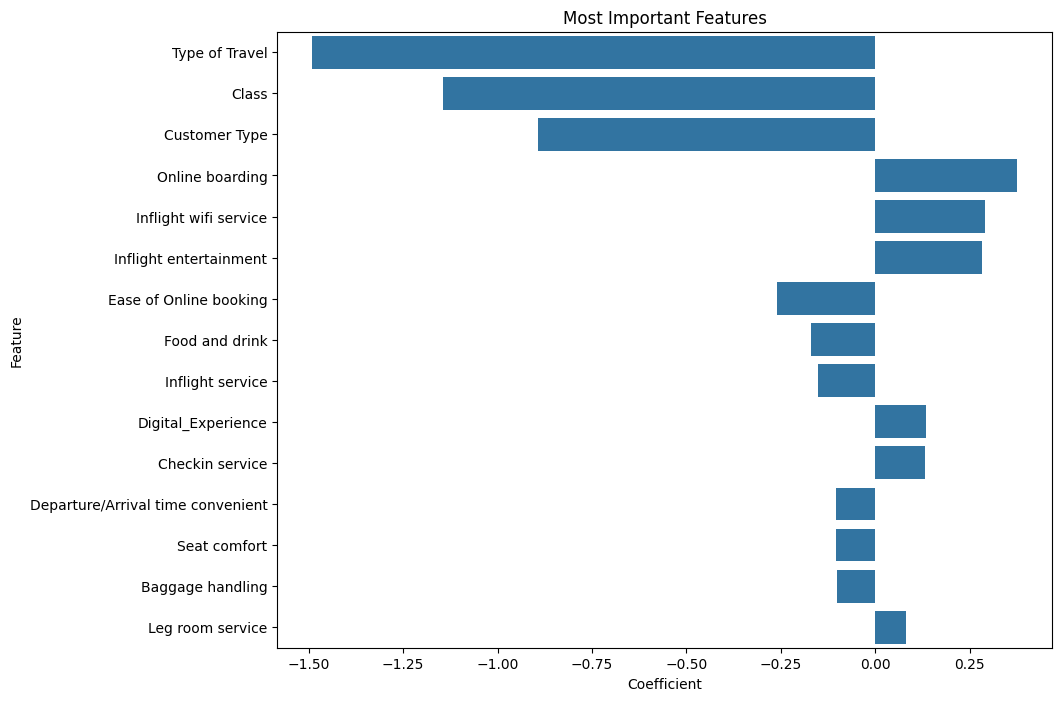

In [18]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(15),

    x="Coefficient",

    y="Feature"

)

plt.title("Most Important Features")

plt.show()

In [19]:
joblib.dump(

    log_model,

    "../models/logistic_regression.pkl"

)

print("Model Saved")

Model Saved


In [20]:
results = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "ROC_AUC"

    ],

    "Score":[

        accuracy,

        precision,

        recall,

        f1,

        auc

    ]

})

results

,Metric,Score
0,Accuracy,0.865021
1,Precision,0.864534
2,Recall,0.816435
3,F1,0.839797
4,ROC_AUC,0.920451


In [21]:
results.to_csv(

    "../reports/classification_results.csv",

    index=False

)

importance.to_csv(

    "../reports/classification_feature_importance.csv",

    index=False
)